Отчет по рубежному контролю

Никифоров Артем Юрьевич

ИУ5-63Б

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('Admission_Predict.csv')

# --- Обработка количественного признака (GRE Score) ---
# Используем заполнение медианой, так как она менее чувствительна к выбросам
df['GRE Score'] = df['GRE Score'].fillna(df['GRE Score'].median())

# --- Обработка категориального признака (University Rating) ---
# Заполняем модой (самым частым рейтингом)
university_mode = df['University Rating'].mode()[0]
df['University Rating'] = df['University Rating'].fillna(university_mode)

print("Пропуски после обработки:")
print(df[['GRE Score', 'University Rating']].isnull().sum())

Пропуски после обработки:
GRE Score            0
University Rating    0
dtype: int64


Какие способы обработки пропусков Вы использовали?

Для количественного признака: Заполнение медианой. Это надежный метод, который сохраняет центральную тенденцию распределения, не искажая данные так сильно, как среднее значение при наличии аномалий.

Для категориального признака: Заполнение модой. Это позволяет сохранить наиболее вероятную категорию для записи, не внося в данные несуществующих классов.

Какие признаки Вы будете использовать для обучения и почему?
Для прогнозирования шанса поступления (Chance of Admit) стоит использовать:

GRE Score, TOEFL Score, CGPA: Это ключевые академические показатели, которые имеют самую высокую корреляцию с целевой переменной.

Research: Опыт исследований часто является определяющим фактором для магистратуры/аспирантуры.

University Rating: Престиж вуза влияет на строгость оценки GPA.

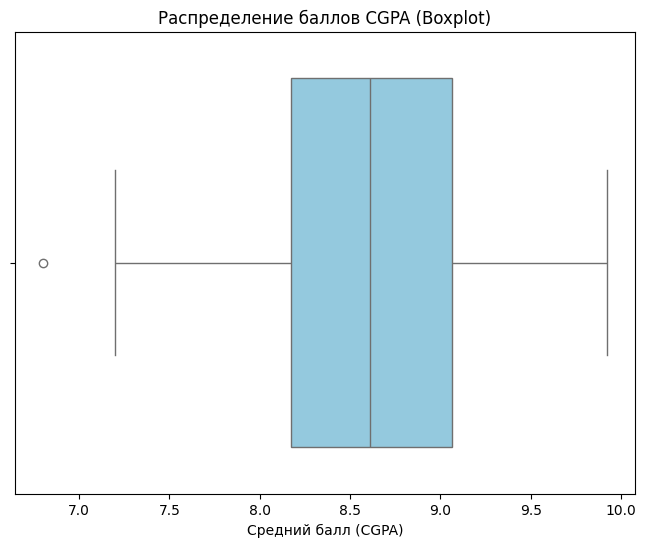

In [2]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['CGPA'], color='skyblue')
plt.title('Распределение баллов CGPA (Boxplot)')
plt.xlabel('Средний балл (CGPA)')
plt.show()